In [ ]:
!wget https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet

--2026-05-03 11:38:22--  https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet
Resolving d37ci6vzurychx.cloudfront.net (d37ci6vzurychx.cloudfront.net)... 99.84.245.141, 99.84.245.193, 99.84.245.157, ...
Connecting to d37ci6vzurychx.cloudfront.net (d37ci6vzurychx.cloudfront.net)|99.84.245.141|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 49961641 (48M) [binary/octet-stream]
Saving to: ‘yellow_tripdata_2024-01.parquet’

yellow_tripdata_202 100%[===================>]  47.65M  83.9MB/s    in 0.6s    

2026-05-03 11:38:23 (83.9 MB/s) - ‘yellow_tripdata_2024-01.parquet’ saved [49961641/49961641]



In [ ]:
import pandas as pd

In [ ]:
df = pd.read_parquet('yellow_tripdata_2024-01.parquet')

In [ ]:
print(f"Shape: {df.shape}")

Shape: (2964624, 19)


In [ ]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,17.7,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,N,79,211,1,10.0,3.5,0.5,2.00,0.0,1.0,17.00,2.5,0.0
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,N,211,148,1,7.9,3.5,0.5,3.20,0.0,1.0,16.10,2.5,0.0


In [ ]:
df_sample = df.sample(frac=0.1, random_state=42)
print(f"New shape: {df_sample.shape}")

New shape: (296462, 19)


In [ ]:
df_sample.isnull().sum()

,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,13989
trip_distance,0
RatecodeID,13989
store_and_fwd_flag,13989
PULocationID,0
DOLocationID,0
payment_type,0


In [ ]:
missing_percent = df_sample.isnull().mean() * 100
print(missing_percent.round(2))

VendorID                 0.00
tpep_pickup_datetime     0.00
tpep_dropoff_datetime    0.00
passenger_count          4.72
trip_distance            0.00
RatecodeID               4.72
store_and_fwd_flag       4.72
PULocationID             0.00
DOLocationID             0.00
payment_type             0.00
fare_amount              0.00
extra                    0.00
mta_tax                  0.00
tip_amount               0.00
tolls_amount             0.00
improvement_surcharge    0.00
total_amount             0.00
congestion_surcharge     4.72
Airport_fee              4.72
dtype: float64


In [ ]:
df_clean = df_sample.dropna(
    subset=['passenger_count', 'RatecodeID', 'store_and_fwd_flag',
            'congestion_surcharge', 'Airport_fee']
)

In [ ]:
print(f"Rows before: {len(df_sample)}")
print(f"Rows after: {len(df_clean)}")
df_clean.info()

Rows before: 296462
Rows after: 282473
<class 'pandas.core.frame.DataFrame'>
Index: 282473 entries, 1725696 to 1298167
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               282473 non-null  int32         
 1   tpep_pickup_datetime   282473 non-null  datetime64[us]
 2   tpep_dropoff_datetime  282473 non-null  datetime64[us]
 3   passenger_count        282473 non-null  float64       
 4   trip_distance          282473 non-null  float64       
 5   RatecodeID             282473 non-null  float64       
 6   store_and_fwd_flag     282473 non-null  object        
 7   PULocationID           282473 non-null  int32         
 8   DOLocationID           282473 non-null  int32         
 9   payment_type           282473 non-null  int64         
 10  fare_amount            282473 non-null  float64       
 11  extra                  282473 non-null  float64       
 12  mta

In [ ]:
df_clean['passenger_count'] = df_clean['passenger_count'].astype(int)

/tmp/ipykernel_868/1847018319.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['passenger_count'] = df_clean['passenger_count'].astype(int)


In [ ]:
df_clean['passenger_count'].value_counts().sort_index()

,count
passenger_count,
0,3228
1,218913
2,40682
3,8954
4,5113
5,3329
6,2250
7,1
8,3


In [ ]:
df_clean.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,282473.000000,282473,282473,282473.000000,282473.000000,282473.000000,282473.000000,282473.000000,282473.00000,282473.000000,282473.000000,282473.000000,282473.000000,282473.000000,282473.000000,282473.000000,282473.000000,282473.000000
mean,1.757495,2024-01-17 01:21:26.524287,2024-01-17 01:36:55.880710,1.337356,3.232780,2.035536,166.286980,165.306939,1.22080,18.008433,1.517772,0.482496,3.416546,0.533877,0.973941,26.761379,2.256499,0.140063
min,1.000000,2023-12-31 23:56:46,2024-01-01 00:03:16,0.000000,0.000000,1.000000,1.000000,1.000000,1.00000,-800.000000,-7.500000,-0.500000,-4.840000,-30.760000,-1.000000,-801.000000,-2.500000,-1.750000
25%,2.000000,2024-01-09 15:27:49,2024-01-09 15:43:27,1.000000,1.000000,1.000000,132.000000,114.000000,1.00000,8.600000,0.000000,0.500000,1.000000,0.000000,1.000000,15.250000,2.500000,0.000000
50%,2.000000,2024-01-17 10:05:50,2024-01-17 10:22:07,1.000000,1.660000,1.000000,162.000000,162.000000,1.00000,12.800000,1.000000,0.500000,2.770000,0.000000,1.000000,19.900000,2.500000,0.000000
75%,2.000000,2024-01-24 18:49:04,2024-01-24 19:04:51,1.000000,3.080000,1.000000,234.000000,234.000000,1.00000,19.800000,2.500000,0.500000,4.200000,0.000000,1.000000,28.300000,2.500000,0.000000
max,2.000000,2024-01-31 23:59:51,2024-02-01 18:41:51,8.000000,207.680000,99.000000,265.000000,265.000000,4.00000,761.100000,11.750000,0.500000,422.700000,87.000000,1.000000,775.480000,2.500000,1.750000
std,0.428599,NaN,NaN,0.848345,4.420855,9.656543,63.209769,69.263803,0.53586,18.527025,1.816291,0.121242,3.971943,2.128743,0.226075,23.197902,0.825429,0.486277


In [ ]:

df_clean = df_clean[
    # Passenger count: 1 to 6 (no 0, no 7+)
    (df_clean['passenger_count'] >= 1) & (df_clean['passenger_count'] <= 6) &

    # Trip distance: greater than 0 and less than 100 miles
    (df_clean['trip_distance'] > 0) & (df_clean['trip_distance'] < 100) &

    # Fare amount: between $2.50 and $200
    (df_clean['fare_amount'] > 2.5) & (df_clean['fare_amount'] < 200) &

    # Total amount: same bounds (it includes fare + everything else)
    (df_clean['total_amount'] > 2.5) & (df_clean['total_amount'] < 200) &

    # Extra surcharges: must be >= 0 and <= reasonable max
    (df_clean['extra'] >= 0) & (df_clean['extra'] <= 20) &
    (df_clean['tip_amount'] >= 0) & (df_clean['tip_amount'] <= 200) &
    (df_clean['tolls_amount'] >= 0) & (df_clean['tolls_amount'] <= 100) &

    # Fixed surcharges: should be non-negative
    (df_clean['improvement_surcharge'] >= 0) &
    (df_clean['congestion_surcharge'] >= 0) &
    (df_clean['Airport_fee'] >= 0)
]

In [ ]:
print(f"Rows before filtering: {282473}")
print(f"Rows after filtering: {len(df_clean)}")
print(f"Percentage kept: {len(df_clean)/282473 * 100:.1f}%")

Rows before filtering: 282473
Rows after filtering: 272116
Percentage kept: 96.3%


In [ ]:
# Calculate trip duration in minutes
df_clean['trip_duration_minutes'] = (
    df_clean['tpep_dropoff_datetime'] - df_clean['tpep_pickup_datetime']
).dt.total_seconds() / 60

In [ ]:
df_clean['trip_duration_minutes'].describe()

,trip_duration_minutes
count,272116.000000
mean,15.626395
std,34.258311
min,-2.883333
25%,7.200000
50%,11.583333
75%,18.600000
max,2077.850000


In [ ]:
df_clean = df_clean[
    (df_clean['trip_duration_minutes'] >= 1) &
    (df_clean['trip_duration_minutes'] <= 180)
]
print(f"Rows after duration filter: {len(df_clean)}")

Rows after duration filter: 271082


In [ ]:
# Extract hour (0-23) and day of week (0=Monday, 6=Sunday)
df_clean['pickup_hour'] = df_clean['tpep_pickup_datetime'].dt.hour
df_clean['pickup_dayofweek'] = df_clean['tpep_pickup_datetime'].dt.dayofweek

In [ ]:
import numpy as np

# Hour: map 0-23 onto a circle
df_clean['hour_sin'] = np.sin(2 * np.pi * df_clean['pickup_hour'] / 24)
df_clean['hour_cos'] = np.cos(2 * np.pi * df_clean['pickup_hour'] / 24)

# Day of week: map 0-6 onto a circle
df_clean['day_sin'] = np.sin(2 * np.pi * df_clean['pickup_dayofweek'] / 7)
df_clean['day_cos'] = np.cos(2 * np.pi * df_clean['pickup_dayofweek'] / 7)

# Verify
print(df_clean[['pickup_hour', 'hour_sin', 'hour_cos']].head(10))

         pickup_hour  hour_sin      hour_cos
1725696           13 -0.258819 -9.659258e-01
1581136           21 -0.707107  7.071068e-01
19137              3  0.707107  7.071068e-01
1682810           22 -0.500000  8.660254e-01
511035            22 -0.500000  8.660254e-01
847543             8  0.866025 -5.000000e-01
1052356            8  0.866025 -5.000000e-01
1366596           18 -1.000000 -1.836970e-16
304475            20 -0.866025  5.000000e-01
989548            15 -0.707107 -7.071068e-01


In [ ]:
# List of features the model is allowed to see (no leakage!)
feature_columns = [
    'VendorID',
    'passenger_count',
    'RatecodeID',
    'PULocationID',
    'DOLocationID',
    'payment_type',
    'hour_sin',
    'hour_cos',
    'day_sin',
    'day_cos'
]

# The target we want to predict
target = 'total_amount'

# Create X (features) and y (target)
X = df_clean[feature_columns]
y = df_clean[target]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (271082, 10)
Target shape: (271082,)


In [ ]:
from sklearn.model_selection import train_test_split

# Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (216865, 10)
Test set: (54217, 10)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Create the model
model = RandomForestRegressor(
    n_estimators=100,   # 100 trees in the forest
    n_jobs=-1,          # use all CPU cores to speed up
    random_state=42     # reproducibility
)

# Train the model on the training data
model.fit(X_train, y_train)

print("✅ Model training complete!")

✅ Model training complete!


In [ ]:
# The forest now predicts the fare for the unseen test set
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE (Mean Absolute Error): ${mae:.2f}")
print(f"RMSE (Root Mean Squared Error): ${rmse:.2f}")

MAE (Mean Absolute Error): $4.09
RMSE (Root Mean Squared Error): $7.05


           feature  importance
2       RatecodeID    0.467023
3     PULocationID    0.271808
4     DOLocationID    0.177825
6         hour_sin    0.017716
7         hour_cos    0.016972
5     payment_type    0.015434
8          day_sin    0.013193
9          day_cos    0.008144
1  passenger_count    0.007215
0         VendorID    0.004671


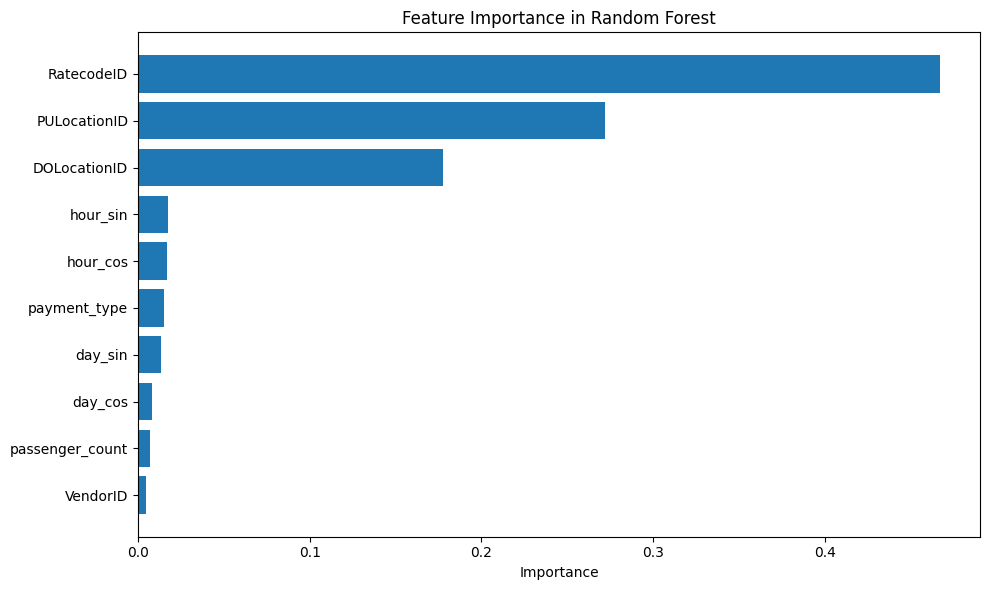

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# feature importances
feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(feat_imp)

# Plot it
plt.figure(figsize=(10, 6))
plt.barh(feat_imp['feature'], feat_imp['importance'])
plt.xlabel('Importance')
plt.title('Feature Importance in Random Forest')
plt.gca().invert_yaxis()  # highest at top
plt.tight_layout()
plt.show()

In [ ]:
!pip install xgboost --quiet

In [ ]:
import xgboost as xgb

# Create and train
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print(f"XGBoost MAE: ${mae_xgb:.2f}")
print(f"XGBoost RMSE: ${rmse_xgb:.2f}")

XGBoost MAE: $6.10
XGBoost RMSE: $9.37


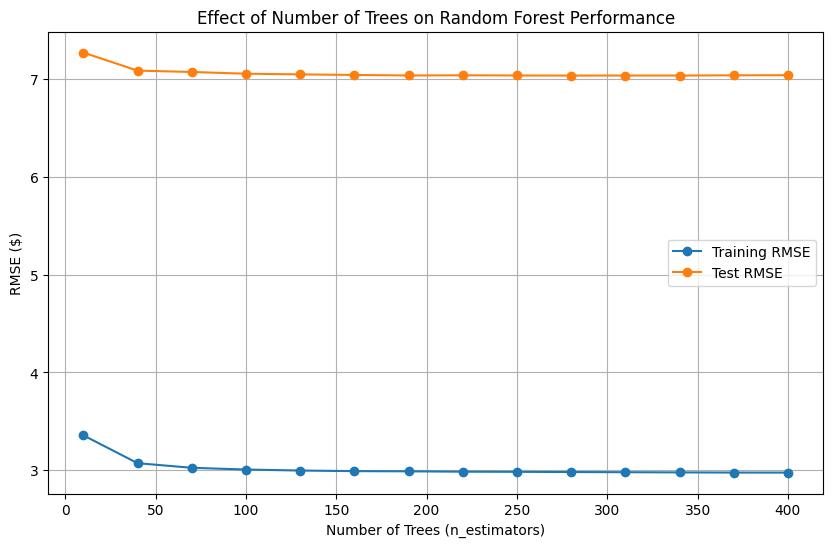

Best test RMSE of 7.03 at n_estimators = 280


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

n_estimators_range = list(range(10, 410, 30))
train_rmse = []
test_rmse = []

for n in n_estimators_range:
    model = RandomForestRegressor(n_estimators=n, n_jobs=-1, random_state=42)
    model.fit(X_train, y_train)
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    train_rmse.append(np.sqrt(mean_squared_error(y_train, train_preds)))
    test_rmse.append(np.sqrt(mean_squared_error(y_test, test_preds)))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, train_rmse, marker='o', label='Training RMSE')
plt.plot(n_estimators_range, test_rmse, marker='o', label='Test RMSE')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('RMSE ($)')
plt.title('Effect of Number of Trees on Random Forest Performance')
plt.legend()
plt.grid(True)
plt.show()

# Print optimal
best_n = n_estimators_range[np.argmin(test_rmse)]
print(f"Best test RMSE of {min(test_rmse):.2f} at n_estimators = {best_n}")

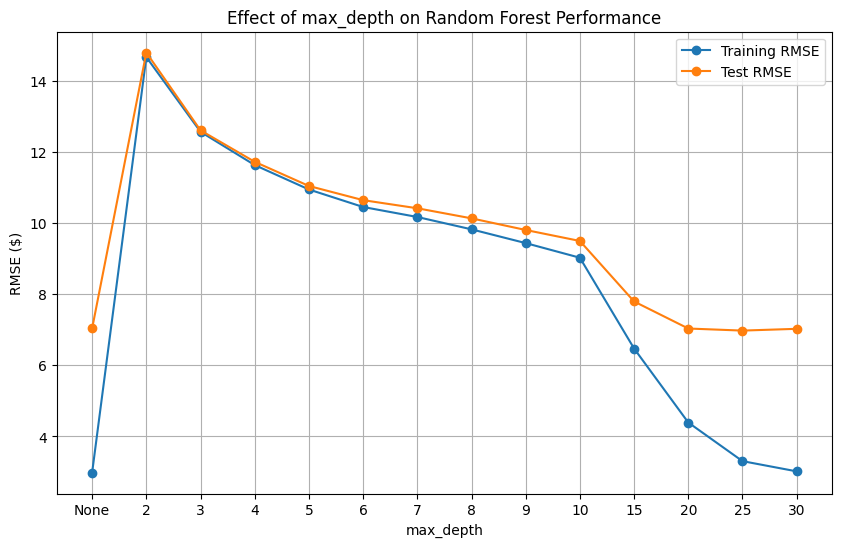

Best Test RMSE: 6.97 at max_depth = 25


In [ ]:
max_depth_range = [None, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30]
train_rmse_d = []
test_rmse_d = []

for depth in max_depth_range:
    model = RandomForestRegressor(
        n_estimators=280,
        max_depth=depth,
        n_jobs=-1,
        random_state=42
    )
    model.fit(X_train, y_train)
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    train_rmse_d.append(np.sqrt(mean_squared_error(y_train, train_preds)))
    test_rmse_d.append(np.sqrt(mean_squared_error(y_test, test_preds)))

# Plot
plt.figure(figsize=(10,6))
plt.plot([str(d) for d in max_depth_range], train_rmse_d, marker='o', label='Training RMSE')
plt.plot([str(d) for d in max_depth_range], test_rmse_d, marker='o', label='Test RMSE')
plt.xlabel('max_depth')
plt.ylabel('RMSE ($)')
plt.title('Effect of max_depth on Random Forest Performance')
plt.legend()
plt.grid(True)
plt.show()

# Find best depth
best_depth = max_depth_range[np.argmin(test_rmse_d)]
print(f"Best Test RMSE: {min(test_rmse_d):.2f} at max_depth = {best_depth}")

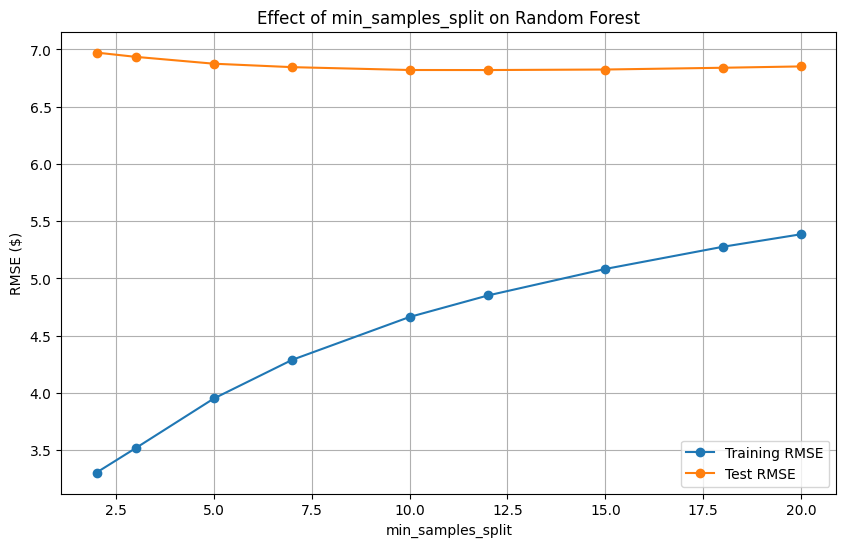

Best Test RMSE: 6.82 at min_samples_split = 12


In [33]:
min_samples_split_range = [2, 3, 5, 7, 10, 12, 15, 18, 20]
train_rmse_s = []
test_rmse_s = []

for mss in min_samples_split_range:
    model = RandomForestRegressor(
        n_estimators=280,
        max_depth=25,
        min_samples_split=mss,
        n_jobs=-1,
        random_state=42
    )
    model.fit(X_train, y_train)
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    train_rmse_s.append(np.sqrt(mean_squared_error(y_train, train_preds)))
    test_rmse_s.append(np.sqrt(mean_squared_error(y_test, test_preds)))

# Plot
plt.figure(figsize=(10,6))
plt.plot(min_samples_split_range, train_rmse_s, marker='o', label='Training RMSE')
plt.plot(min_samples_split_range, test_rmse_s, marker='o', label='Test RMSE')
plt.xlabel('min_samples_split')
plt.ylabel('RMSE ($)')
plt.title('Effect of min_samples_split on Random Forest')
plt.legend()
plt.grid(True)
plt.show()

best_mss = min_samples_split_range[np.argmin(test_rmse_s)]
print(f"Best Test RMSE: {min(test_rmse_s):.2f} at min_samples_split = {best_mss}")

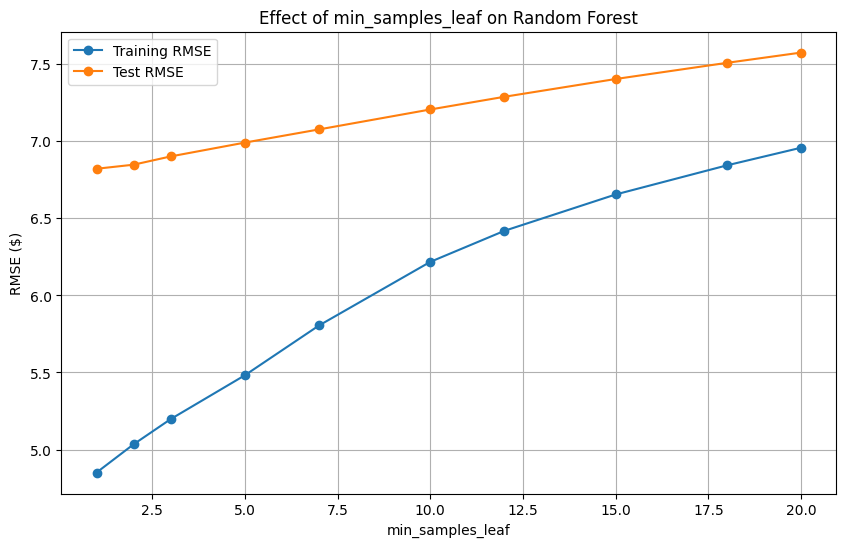

Best Test RMSE: 6.82 at min_samples_leaf = 1


In [34]:
min_samples_leaf_range = [1, 2, 3, 5, 7, 10, 12, 15, 18, 20]
train_rmse_l = []
test_rmse_l = []

for msl in min_samples_leaf_range:
    model = RandomForestRegressor(
        n_estimators=280,
        max_depth=25,
        min_samples_split=12,
        min_samples_leaf=msl,
        n_jobs=-1,
        random_state=42
    )
    model.fit(X_train, y_train)
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    train_rmse_l.append(np.sqrt(mean_squared_error(y_train, train_preds)))
    test_rmse_l.append(np.sqrt(mean_squared_error(y_test, test_preds)))

# Plot
plt.figure(figsize=(10,6))
plt.plot(min_samples_leaf_range, train_rmse_l, marker='o', label='Training RMSE')
plt.plot(min_samples_leaf_range, test_rmse_l, marker='o', label='Test RMSE')
plt.xlabel('min_samples_leaf')
plt.ylabel('RMSE ($)')
plt.title('Effect of min_samples_leaf on Random Forest')
plt.legend()
plt.grid(True)
plt.show()

best_msl = min_samples_leaf_range[np.argmin(test_rmse_l)]
print(f"Best Test RMSE: {min(test_rmse_l):.2f} at min_samples_leaf = {best_msl}")

In [35]:
# Final tuned model
final_model = RandomForestRegressor(
    n_estimators=280,
    max_depth=25,
    min_samples_split=12,
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=42
)

final_model.fit(X_train, y_train)

# Predictions
y_pred_final = final_model.predict(X_test)

# Both metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

final_mae = mean_absolute_error(y_test, y_pred_final)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))

print(f"Final Tuned Model MAE:  ${final_mae:.2f}")
print(f"Final Tuned Model RMSE: ${final_rmse:.2f}")

Final Tuned Model MAE:  $3.93
Final Tuned Model RMSE: $6.82


In [38]:
!pip install mlflow --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20

In [39]:
import mlflow
import mlflow.sklearn

with mlflow.start_run(run_name="RandomForest_Tuned"):
    # Log the winning hyperparameters
    mlflow.log_param("model_type", "RandomForestRegressor")
    mlflow.log_param("n_estimators", 280)
    mlflow.log_param("max_depth", 25)
    mlflow.log_param("min_samples_split", 12)
    mlflow.log_param("min_samples_leaf", 1)

    # Log the final metrics
    mlflow.log_metric("MAE", 3.93)
    mlflow.log_metric("RMSE", 6.82)

    # Save the trained model itself
    mlflow.sklearn.log_model(final_model, "tuned_random_forest")

    print("✅ Tuned run logged.")
    print(f"Run ID: {mlflow.active_run().info.run_id}")

2026/05/03 14:49:37 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/03 14:49:37 INFO mlflow.store.db.utils: Updating database tables
2026/05/03 14:49:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 14:49:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Tuned run logged.
Run ID: b76704c6da2448f5adfbed33c71aa479


In [40]:
%%writefile requirements.txt
pandas
numpy
scikit-learn
xgboost
mlflow
matplotlib
seaborn
pyarrow

Writing requirements.txt
